
# Spectral Analysis of Paleoclimate Time Series
## REDFIT (Schulz & Mudelsee, 2002) + WWZ Wavelet (Foster, 1996)
### A Reference Notebook for Unevenly Sampled Geological Data

**Version:** 1.0 &nbsp;|&nbsp; **Engine:** redfit38e.f90 (Exact Fortran port, created 06-08-2026) &nbsp;|&nbsp; **Author:** V. H. Arjun, N. M. Gayathri

---

### Key References
- **Schulz, M. & Mudelsee, M. (2002).** REDFIT: estimating red-noise spectra directly from unevenly spaced paleoclimatic time series. *Computers & Geosciences*, 28(3), 421–426. https://doi.org/10.1016/S0098-3004(01)00044-9
- **Foster, G. (1996).** Wavelets for period analysis of unevenly sampled time series. *The Astronomical Journal*, 112(4), 1709–1729. https://doi.org/10.1086/118137
- **Press, W.H. et al. (1992).** *Numerical Recipes in Fortran 77*, 2nd ed. Cambridge University Press.

---

### How to Use This Notebook

> Run cells **from top to bottom**. The notebook is self-guiding.
>
> - Cells labelled **USER INPUT BLOCK** are the **only** cells that need to be edited.
> - All other cells — especially the REDFIT engine — should be run without changes.
> - Every code cell has a markdown explanation **before** it and an interpretation guide **after** it.

---



---
## Section 1: Why Standard Spectral Analysis Fails for Paleoclimate Data

### The Core Problem: Uneven Sampling
All standard spectral analysis algorithms — including the Fast Fourier Transform (FFT), Discrete Fourier Transform (DFT), and classical periodogram — rest on the **Nyquist-Shannon sampling theorem**, which assumes that data is measured at *perfectly regular* intervals. The mathematics literally cannot work without this assumption.

Geological and paleoclimate records are inherently uneven. Sediment cores accumulate at variable rates driven by climate, tectonics, and oceanographic processes. Bioturbation mixes sediment vertically. Core sections are lost during recovery. The result is a time series with a distribution of sampling intervals that can vary by a factor of 2 to 10× within a single record.

### The Danger of Interpolation
The naive solution of interpolating the data onto a regular grid before applying FFT, is **mathematically dangerous** and should be avoided for paleoclimate work:

1. **Variance inflation**: Interpolation between widely-spaced points invents data. This inflates the variance at frequencies corresponding to the interpolation interval, creating spectral peaks that have no physical origin.
2. **Spectral reddening**: The smoothing implicit in interpolation amplifies low-frequency power, artificially reddening the spectrum and making it harder to distinguish real climate cycles from the mathematical artefact.
3. **False peaks**: In extreme cases, regular interpolation introduces a periodic signal at the interpolation frequency itself, which can appear as a statistically significant "climate cycle."

### The Correct Solution

This notebook uses two algorithms specifically designed for unevenly spaced data:

| Method | What It Does | When to Use |
|--------|-------------|-------------|
| **REDFIT** (Lomb-Scargle) | Finds *average* dominant periodicities over the entire record | Always — the primary spectral test |
| **WWZ Wavelet** | Maps spectral power through *time*, showing which cycles were active *when* | Complementary — detects non-stationarity |

Both algorithms work directly with the uneven time coordinates. **No interpolation is ever performed.**



---
## Section 2: Scientific Software Stack

The cell below loads all required Python packages. Here is what each one does and why it is needed:

| Library | Purpose in This Notebook |
|---------|--------------------------|
| `numpy` | Core numerical arrays and fast vectorized mathematics (matrix operations, trigonometry, sorting). The REDFIT engine is written entirely in numpy. |
| `pandas` | Reading Excel/CSV files, handling heterogeneous data types, and displaying formatted tables. |
| `matplotlib` | All figures and plots. The `ScalarFormatter` is needed for the non-standard period axis. |
| `math` | Python's built-in scalar math functions (e.g., `math.sqrt`, `math.log`). Used in the engine for single-value computations where numpy overhead is unnecessary. |
| `scipy.special.gammainc` | The regularized incomplete gamma function — needed by the `getchi2()` function to compute exact Chi² quantiles matching the Fortran REDFIT source. |
| `scipy.stats.norm` | Normal distribution percentiles — needed by `getchi2()` for the Sachs (1984) large-DOF approximation. |
| `scipy.signal.find_peaks` | Algorithmic detection of local maxima in the spectrum. Ensures we detect all peaks objectively. |
| `pyleoclim` | Implements the WWZ (Weighted Wavelet Z-Transform) for unevenly spaced data and handles surrogate significance testing against an uneven AR(1) background. |
| `os`, `sys`, `datetime` | File path handling, Python version querying, and timestamp generation for the reproducibility log. |
| `warnings` | The REDFIT engine emits targeted warnings (e.g., when tau estimation is unreliable). We keep these visible — they carry scientifically important information. |

> **Note on Windows:** `pyleoclim` uses Python multiprocessing for its significance tests. On Windows, this can cause crashes if multiple worker processes are spawned from a notebook. The `try/except` block below safely forces single-core operation.


In [9]:
# =============================================================================
# LIBRARY IMPORTS & ENVIRONMENT SETUP  (do not edit)
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter
import math, os, sys, datetime, warnings
from scipy.special import gammainc
from scipy.stats import norm as _norm
from scipy.signal import find_peaks
import pyleoclim as pyleo

# Windows multiprocessing safety fix for pyleoclim
try:
    pyleo.core.multipleseries.POOL_WORKERS = 1
except AttributeError:
    pass

# Publication-quality global plot settings
plt.rcParams.update({
    "figure.dpi"      : 150,
    "font.family"     : "sans-serif",
    "font.size"       : 12,
    "axes.linewidth"  : 1.5,
    "axes.labelsize"  : 13,
    "axes.titlesize"  : 15,
    "xtick.direction" : "in",
    "ytick.direction" : "in",
    "legend.framealpha": 0.9,
})

print(f"Python {sys.version}")
print(f"numpy  {np.__version__}   pandas {pd.__version__}   pyleoclim {pyleo.__version__}")
print("Environment ready.")


Python 3.11.15 | packaged by conda-forge | (main, Aug 11 2026, 10:17:41) [MSC v.1944 64 bit (AMD64)]
numpy  1.26.4   pandas 3.0.5   pyleoclim 1.2.1
Environment ready.



---
## Section 3: Loading Your Data

### File Requirements
Place the data file in the **same folder as this notebook**. The following formats are accepted:

| Format | Notes |
|--------|-------|
| `.xlsx` (Excel) | Specify the sheet name. Works with multi-sheet workbooks. |
| `.csv` (Comma-Separated) | Must have a header row. Sheet name is ignored. |

### Column Requirements
The file must contain at minimum two numeric columns:
- **Age / Time axis**: A monotonically increasing (or decreasing) sequence of ages. This notebook assumes **age in thousands of years (ka)**. If the data is in years, depth, or another unit, it needs to be converted before use.
- **Proxy column**: The paleoclimate signal that needs to be analysed (e.g., δ¹⁸O, SST, foram percentage). Any numeric proxy is accepted.

### What the Code Does
The cell below will:
1. Check that the file exists and print an error with available files if it does not.
2. Load the file and print all available column names with their data counts.
3. Display the first 5 rows to verify that the data loaded correctly.

**After running this cell**, identify the age column and proxy column from the printed list, then edit the next input block.


In [10]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  USER INPUT BLOCK 1 — File & Sheet Selection                 ║
# ║  Edit the two lines below, then run this cell.               ║
# ╚══════════════════════════════════════════════════════════════╝

FILE_NAME  = '15ka.xlsx'   # ← Enter your filename (must be in the same folder)
SHEET_NAME = 'Sheet1'      # ← Excel sheet name (ignored for .csv files)

# ─── Automated loading (do not edit below) ───────────────────────────────────
if not os.path.exists(FILE_NAME):
    print("CRITICAL ERROR: File not found.  Files available in current folder:")
    for f in sorted(os.listdir('.')):
        if f.lower().endswith(('.xlsx', '.csv', '.xls')):
            print(f"  → {f}")
    raise FileNotFoundError(f"Cannot find '{FILE_NAME}'.")

if FILE_NAME.lower().endswith('.csv'):
    df_raw = pd.read_csv(FILE_NAME)
    print(f"Loaded CSV: '{FILE_NAME}'")
else:
    xls = pd.ExcelFile(FILE_NAME)
    if SHEET_NAME not in xls.sheet_names:
        raise ValueError(
            f"Sheet '{SHEET_NAME}' not found.  Available sheets: {xls.sheet_names}"
        )
    df_raw = pd.read_excel(xls, sheet_name=SHEET_NAME)
    print(f"Loaded Excel: '{FILE_NAME}'  /  Sheet: '{SHEET_NAME}'")

df_raw.columns = df_raw.columns.str.strip()

print(f"\nAvailable columns ({len(df_raw.columns)} total):")
for col in df_raw.columns:
    dtype = df_raw[col].dtype
    nn    = df_raw[col].count()
    print(f"  '{col}'  ← dtype={dtype}, {nn} non-null values")

print("\nFirst 5 rows:")
display(df_raw.head())


Loaded Excel: '15ka.xlsx'  /  Sheet: 'Sheet1'

Available columns (21 total):
  'Age Ka'  ← dtype=float64, 85 non-null values
  '% N. dutertrei'  ← dtype=float64, 85 non-null values
  '% siphonifera'  ← dtype=float64, 85 non-null values
  '% obliquiloculata'  ← dtype=float64, 85 non-null values
  '% venezulana'  ← dtype=float64, 85 non-null values
  '% glutinata'  ← dtype=float64, 85 non-null values
  '% bulloides'  ← dtype=float64, 85 non-null values
  '% ruber'  ← dtype=float64, 85 non-null values
  '% universa'  ← dtype=float64, 85 non-null values
  '% sacculifer'  ← dtype=float64, 85 non-null values
  '% menardii'  ← dtype=float64, 85 non-null values
  '% susceptible species'  ← dtype=float64, 85 non-null values
  'G.bulloides/G. ruber'  ← dtype=float64, 85 non-null values
  'fertile species'  ← dtype=float64, 85 non-null values
  'Unnamed: 14'  ← dtype=float64, 0 non-null values
  'Age Ka.1'  ← dtype=float64, 85 non-null values
  '% N. dutertrei.1'  ← dtype=float64, 85 non-null val

,Age Ka,% N. dutertrei,% siphonifera,% obliquiloculata,% venezulana,% glutinata,% bulloides,% ruber,% universa,% sacculifer,...,% susceptible species,G.bulloides/G. ruber,fertile species,Unnamed: 14,Age Ka.1,% N. dutertrei.1,% obliquiloculata.1,% venezulana.1,% menardii.1,Resistant species
0,1.747000,16.888889,12.444444,1.777778,9.333333,0.444444,0.444444,2.222222,4.000000,1.777778,...,8.000000,0.200000,0.888889,NaN,1.747000,16.888889,1.777778,9.333333,6.666667,34.666667
1,1.990698,12.851406,10.441767,0.401606,7.630522,0.401606,1.204819,2.222222,0.444444,6.222222,...,8.032129,0.542169,1.606426,NaN,1.990698,12.851406,0.401606,7.630522,11.111111,31.994645
2,2.234395,26.315789,27.751196,1.435407,7.177033,2.392344,0.478469,1.333333,3.555556,3.555556,...,9.090909,0.358852,2.870813,NaN,2.234395,26.315789,1.435407,7.177033,7.555556,42.483785
3,2.478093,14.545455,11.363636,1.818182,8.636364,1.818182,0.909091,2.666667,2.222222,4.444444,...,9.545455,0.340909,2.727273,NaN,2.478093,14.545455,1.818182,8.636364,15.111111,40.111111
4,2.721791,12.295082,12.295082,1.639344,9.016393,1.229508,0.819672,1.777778,1.333333,5.333333,...,7.786885,0.461066,2.049180,NaN,2.721791,12.295082,1.639344,9.016393,12.000000,34.950820



From the column list printed above, identify:
- The **age column** (time axis — should be numeric, monotonic)
- The **proxy column** (the climate signal)

Copy the **exact column names** (including spaces and special characters like `%`, `δ`, `.`) and paste them into the cell below.


In [11]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  USER INPUT BLOCK 2 — Column Selection                       ║
# ║  Paste exact column names from the table above.              ║
# ╚══════════════════════════════════════════════════════════════╝

AGE_COLUMN   = 'Age Ka'           # ← Your age/time column
PROXY_COLUMN = '% N. dutertrei'   # ← Your proxy column

# ─── Automated extraction (do not edit below) ─────────────────────────────────
for col, label in [(AGE_COLUMN, 'AGE_COLUMN'), (PROXY_COLUMN, 'PROXY_COLUMN')]:
    if col not in df_raw.columns:
        raise ValueError(
            f"{label}='{col}' not found in the dataset.\n"
            f"Available columns: {df_raw.columns.tolist()}"
        )

series = (df_raw[[AGE_COLUMN, PROXY_COLUMN]]
          .dropna()
          .sort_values(AGE_COLUMN)
          .reset_index(drop=True))

global_time       = series[AGE_COLUMN].to_numpy(dtype=float)
global_proxy      = series[PROXY_COLUMN].to_numpy(dtype=float)
global_proxy_name = PROXY_COLUMN

dt_arr   = np.diff(global_time)
mean_dt  = np.mean(dt_arr)

print(f"  Proxy      : {global_proxy_name}")
print(f"  N points   : {len(global_time)}")
print(f"  Age range  : {global_time.min():.4f} – {global_time.max():.4f}")
print(f"  Mean Δt    : {mean_dt:.4f}")
print(f"  Proxy mean : {np.mean(global_proxy):.4f}")
print(f"  Proxy std  : {np.std(global_proxy, ddof=1):.4f}")
print("\nData successfully loaded. Proceed to the EDA section.")


  Proxy      : % N. dutertrei
  N points   : 85
  Age range  : 1.7470 – 15.1950
  Mean Δt    : 0.1601
  Proxy mean : 16.0072
  Proxy std  : 6.5112

Data successfully loaded. Proceed to the EDA section.



---
## Section 4: Exploratory Data Analysis (EDA)

**Do not skip this section.** A surprising number of spectral analysis errors stem from unexpected data properties that are invisible until you look at the raw record. The EDA dashboard below checks for the most common pitfalls.

### What to Look For in Each Panel

**Panel 1: Raw Time Series**
- Look for obvious **outliers** (extreme values). A single outlier can dominate the spectrum entirely.
- Look for **data gaps** — long horizontal stretches with no points. Gaps wider than the cycle you are looking for make that cycle undetectable.
- The proxy values should have a physically reasonable range for the geological context.

**Panel 2: Sampling Interval Histogram**
- A tight, symmetric distribution means the sampling is relatively even.
- A wide, skewed distribution (or bimodal) indicates highly irregular sampling.
- The **Coefficient of Variation (CV = σ/μ)** quantifies this:
  - CV < 0.1 → very even → standard FFT *could* work (but REDFIT is still safer)
  - 0.1 < CV < 0.3 → moderate unevenness → REDFIT strongly recommended
  - CV > 0.3 → high unevenness → **REDFIT and WWZ are required**

**Panel 3: Lag-Time Correlogram**
- This shows autocorrelation at physical time lags (multiples of mean Δt), not sample lags.
- **Slowly decaying bars** (rho still high at lag 5–10) = strong "red noise" persistence. The red noise curve on your spectrum will be steep and dominate the low frequencies.
- **Rapid decay to zero** (by lag 2–3) = nearly white noise. The red noise curve will be nearly flat, and peaks are easier to identify.
- **Oscillating pattern** (positive then negative) = possible aliasing or quasi-periodic background. Interpret with care.


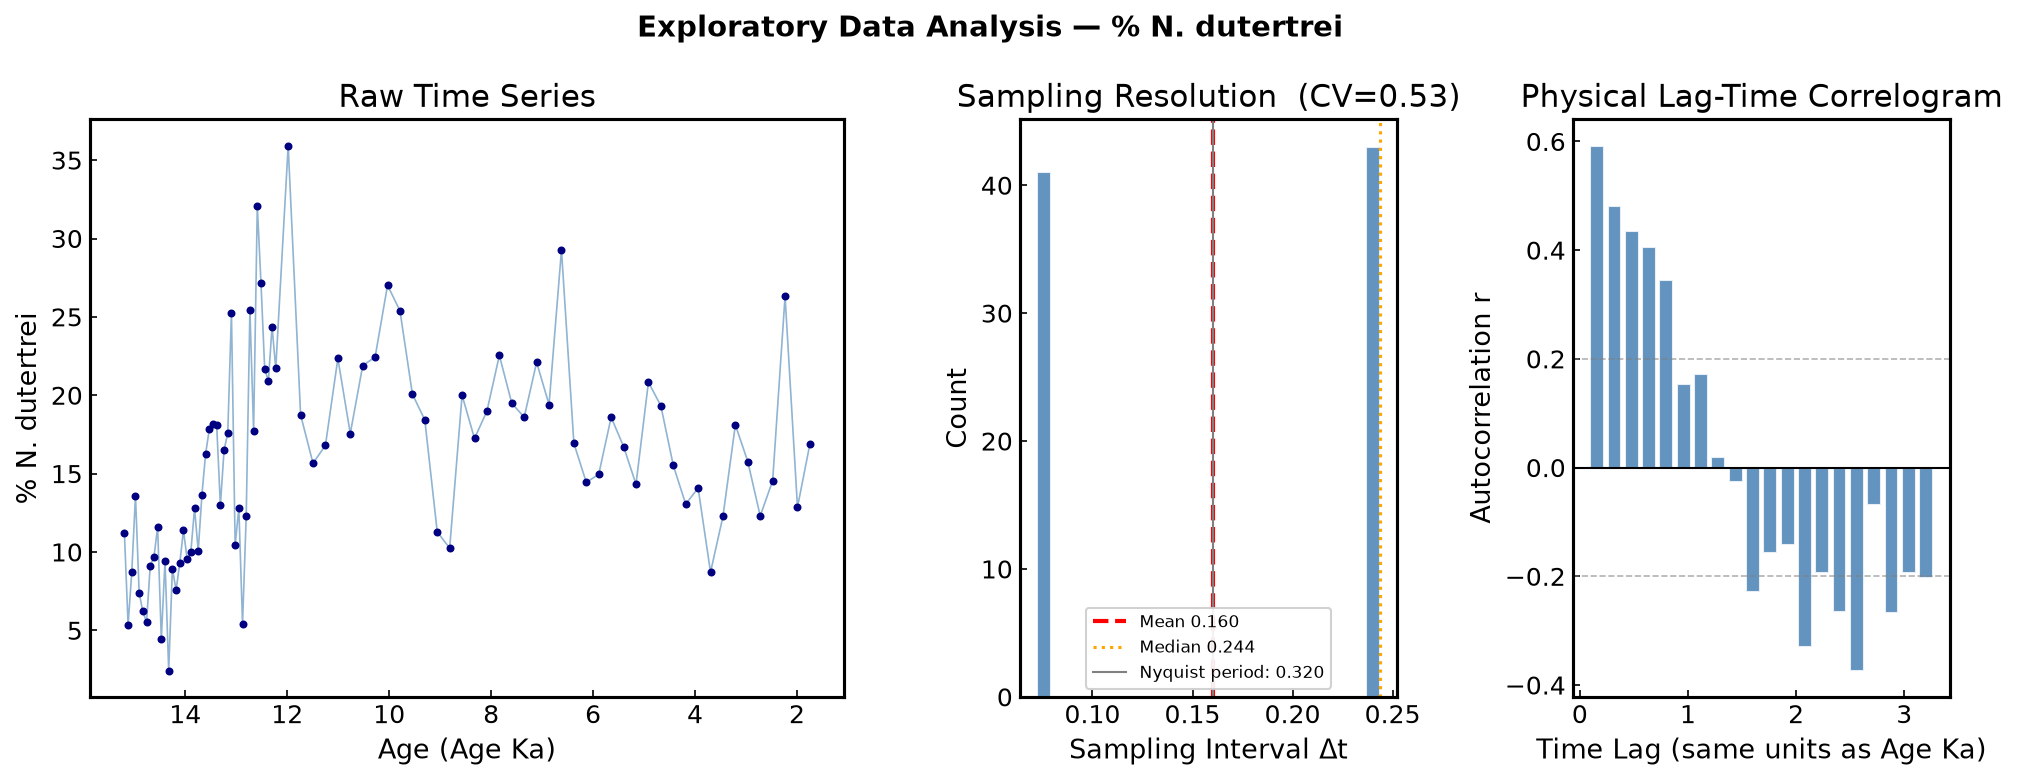

  SAMPLING DIAGNOSTICS
  Age range       : 1.7470 – 15.1950
  N data points   : 85
  Mean Δt         : 0.1601
  Median Δt       : 0.2437
  Min Δt          : 0.0724
  Max Δt          : 0.2437
  Max/Mean ratio  : 1.52  (> 3 = significant gap)
  Coeff of Var    : 0.535  ← HIGH: use Lomb-Scargle/WWZ
  Nyquist period  : 0.3202  (shortest detectable cycle)


In [12]:
# =============================================================================
# EDA DASHBOARD  (do not edit)
# =============================================================================
dt_arr     = np.diff(global_time)
reversals  = int(np.sum(dt_arr < 0))
duplicates = int(np.sum(dt_arr == 0))
mean_dt    = float(np.mean(dt_arr))
median_dt  = float(np.median(dt_arr))
cv         = float(np.std(dt_arr) / mean_dt) if mean_dt != 0 else 0.0
nyq_period = 2.0 * mean_dt   # Nyquist period in same units as age

# ── Physical lag-time correlogram ─────────────────────────────────────────────
# For uneven data, pd.autocorr(lag=k) computes correlation at lag-k SAMPLES,
# which is physically meaningless when Δt varies.  Instead we bin all data
# pairs by their time separation and compute Pearson r in each bin.
max_lag_time = 20 * mean_dt
n_lag_bins   = 20
lag_centers  = np.linspace(mean_dt, max_lag_time, n_lag_bins)
half_bin     = (lag_centers[1] - lag_centers[0]) / 2.0
proxy_z      = global_proxy - np.mean(global_proxy)   # zero-mean for Pearson r

acf_vals  = np.full(n_lag_bins, np.nan)
acf_n     = np.zeros(n_lag_bins, dtype=int)
for bi, lc in enumerate(lag_centers):
    lo, hi = lc - half_bin, lc + half_bin
    pairs_i, pairs_j = [], []
    for i in range(len(global_time)):
        for j in range(i + 1, len(global_time)):
            sep = abs(global_time[j] - global_time[i])
            if lo <= sep < hi:
                pairs_i.append(i); pairs_j.append(j)
            elif sep >= hi:
                break
    if len(pairs_i) >= 3:
        x = np.array([proxy_z[k] for k in pairs_i])
        y = np.array([proxy_z[k] for k in pairs_j])
        denom = np.sqrt(np.sum(x**2) * np.sum(y**2))
        acf_vals[bi] = np.dot(x, y) / denom if denom > 0 else np.nan
        acf_n[bi]    = len(pairs_i)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 5))
gs  = fig.add_gridspec(1, 3, width_ratios=[2.2, 1.1, 1.1], wspace=0.35)

# ── Panel 1: Raw time series ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(global_time, global_proxy, color='steelblue', lw=0.8, alpha=0.6)
ax1.scatter(global_time, global_proxy, c='navy', s=8, zorder=3)
ax1.set_xlabel(f"Age ({AGE_COLUMN})")
ax1.set_ylabel(global_proxy_name)
ax1.set_title("Raw Time Series")
if global_time[-1] > global_time[0]:
    ax1.invert_xaxis()   # geological convention: oldest on right

# ── Panel 2: Δt histogram ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.hist(dt_arr, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
ax2.axvline(mean_dt,   color='red',    lw=2, ls='--', label=f"Mean {mean_dt:.3f}")
ax2.axvline(median_dt, color='orange', lw=1.5, ls=':', label=f"Median {median_dt:.3f}")
ax2.axvline(nyq_period/2, color='gray', lw=1, ls='-',
            label=f"Nyquist period: {nyq_period:.3f}")
ax2.set_xlabel("Sampling Interval Δt")
ax2.set_ylabel("Count")
ax2.set_title(f"Sampling Resolution  (CV={cv:.2f})")
ax2.legend(fontsize=8)

# ── Panel 3: Physical lag-time correlogram ────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
valid = ~np.isnan(acf_vals)
ax3.bar(lag_centers[valid], acf_vals[valid], width=half_bin * 1.6,
        color='steelblue', edgecolor='white', alpha=0.85)
ax3.axhline(0, color='black', lw=1)
ax3.axhline( 0.2, color='gray', lw=0.8, ls='--', alpha=0.6)
ax3.axhline(-0.2, color='gray', lw=0.8, ls='--', alpha=0.6)
ax3.set_xlabel(f"Time Lag (same units as {AGE_COLUMN})")
ax3.set_ylabel("Autocorrelation r")
ax3.set_title("Physical Lag-Time Correlogram")

plt.suptitle(f"Exploratory Data Analysis — {global_proxy_name}", fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"EDA_{global_proxy_name.replace('%','Pct').replace(' ','_').replace('.','').replace('/','_')}.png",
            dpi=200, bbox_inches='tight')
plt.show()

# ── Diagnostics table ─────────────────────────────────────────────────────────
print("=" * 52)
print("  SAMPLING DIAGNOSTICS")
print("=" * 52)
print(f"  Age range       : {global_time.min():.4f} – {global_time.max():.4f}")
print(f"  N data points   : {len(global_time)}")
print(f"  Mean Δt         : {mean_dt:.4f}")
print(f"  Median Δt       : {median_dt:.4f}")
print(f"  Min Δt          : {np.min(dt_arr):.4f}")
print(f"  Max Δt          : {np.max(dt_arr):.4f}")
print(f"  Max/Mean ratio  : {np.max(dt_arr)/mean_dt:.2f}  (> 3 = significant gap)")
print(f"  Coeff of Var    : {cv:.3f}  {'← HIGH: use Lomb-Scargle/WWZ' if cv > 0.3 else '← Moderate: REDFIT still recommended'}")
print(f"  Nyquist period  : {nyq_period:.4f}  (shortest detectable cycle)")
if reversals > 0:
    print(f"  ⚠️  Age reversals : {reversals}  (must fix before proceeding)")
if duplicates > 0:
    print(f"  ⚠️  Duplicate ages : {duplicates}  (may cause numerical issues)")
print("=" * 52)



### How to Interpret the EDA Output

**Coefficient of Variation (CV)**

| CV Value | Spacing | Recommendation |
|----------|---------|----------------|
| < 0.1 | Very even | FFT could work, but REDFIT is always safer |
| 0.1 – 0.3 | Moderate | REDFIT strongly recommended |
| 0.3 – 0.6 | High | REDFIT + WWZ required |
| > 0.6 | Very high | Check for data gaps; consider if the record is suitable |

**Nyquist Period:** The shortest cycle this dataset can detect is 2 × mean_Δt. If you are looking for, say, a 1,000-year (1 ka) cycle, your mean sampling interval must be ≤ 500 years (0.5 ka). Cycles shorter than the Nyquist period are undetectable.

**Max/Mean Δt Ratio:** A ratio > 3 means there are gaps more than 3× the average spacing. Such gaps can cause spectral smearing — a sharp cycle will appear broader than it really is.

**Age Reversals:** If any are detected, your data is not monotonically ordered. This will corrupt both the REDFIT tau estimation and the WWZ computation. Return to your raw data and correct the age model before proceeding.

**Lag-Time Correlogram:** The gray dashed lines mark ±0.2. If the first lag bar is:
- **> 0.5**: Strong red noise. The red noise baseline will dominate the spectrum. Only very prominent peaks will be significant.
- **0.2 – 0.5**: Moderate red noise. Typical for most paleoclimate proxies.
- **< 0.2**: Near-white noise. The red noise baseline will be relatively flat and easy to interpret.

> **If the correlogram shows an oscillating (alternating positive/negative) pattern**, this suggests possible aliasing or a strong periodic signal in the raw data itself. This is a warning sign worth investigating before spectral analysis.



---
## Section 5: The REDFIT Algorithm: Full Theory

### 5.1 The Lomb-Scargle Transform

Instead of computing a Discrete Fourier Transform (which requires evenly spaced data), REDFIT uses the **Lomb-Scargle transform** (Lomb 1976, Scargle 1982). At each test frequency $f$, it asks: "How well does a sinusoid of frequency $f$ fit my data?" using a weighted least-squares fit:

$$\text{Power}(f) = \frac{1}{2} \left[ \frac{\left(\sum_i x_i \cos(\omega t_i - \tau)\right)^2}{\sum_i \cos^2(\omega t_i - \tau)} + \frac{\left(\sum_i x_i \sin(\omega t_i - \tau)\right)^2}{\sum_i \sin^2(\omega t_i - \tau)} \right]$$

where $\omega = 2\pi f$, and $\tau$ is a phase offset that makes the estimator statistically equivalent to the classical periodogram for evenly spaced data (Scargle's tau correction).

### 5.2 WOSA — Welch's Overlapping Segment Averaging

A single spectrum computed over the entire record is noisy — individual spectral estimates have large uncertainty. REDFIT optionally splits the record into $n_{50}$ overlapping **segments** (each successive segment starting halfway through the previous one, hence "50% overlap"), computes a Lomb-Scargle spectrum for each, and averages them.

**The fundamental trade-off:**

| Parameter | Effect on resolution | Effect on noise |
|-----------|---------------------|-----------------|
| n50 = 1 (no segmenting) | Best frequency resolution | Highest noise |
| n50 = 2 | Halved resolution | Noise reduced by ~√2 |
| n50 = 3 | Thirds of resolution | Noise reduced by ~√3 |

For short paleoclimate records (< 500 points), **n50 = 1 is almost always recommended**. The frequency resolution is already limited by the record length; further reducing it with segmenting is counterproductive.

### 5.3 The AR(1) Red Noise Model

Most paleoclimate proxies exhibit **persistence**: a warm period tends to be followed by another warm period, not an immediate cold reversal. This "memory" in the climate system is modelled mathematically as a first-order autoregressive (AR(1)) process:

$$x(t_i) = \rho(t_i) \cdot x(t_{i-1}) + \sigma(t_i) \cdot \varepsilon_i$$

where $\varepsilon_i \sim \mathcal{N}(0,1)$ and:
- $\rho(t_i) = e^{-\Delta t_i / \tau}$ is the lag-1 autocorrelation coefficient at each *uneven* step
- $\tau$ is the **persistence time** (e-folding time, in same units as age): how long the climate "remembers" a perturbation
- $\sigma(t_i) = \sqrt{1 - e^{-2\Delta t_i / \tau}}$ is the innovation standard deviation

The theoretical power spectrum of this AR(1) process is a **red noise curve** (high power at low frequencies, declining towards high frequencies):

$$G_{\text{red}}(f) \propto \frac{1 - \rho^2}{1 - 2\rho\cos(\pi f / f_N) + \rho^2}$$

where $f_N$ is the Nyquist frequency and $\rho$ is the autocorrelation at the mean sampling interval.

### 5.4 Physical Meaning of τ and ρ

| Proxy type | Typical τ | Typical ρ |
|-----------|-----------|-----------|
| Open-ocean planktonic forams (Holocene) | 0.1 – 0.5 ka | 0.1 – 0.4 |
| Benthic forams (Quaternary) | 0.5 – 3 ka | 0.3 – 0.7 |
| Speleothem δ¹⁸O | 0.05 – 0.3 ka | 0.05 – 0.3 |
| Ice-core records | 0.001 – 0.05 ka | 0.1 – 0.5 |
| Orbital-scale records (100 ka) | 5 – 30 ka | 0.5 – 0.9 |

If your computed τ falls far outside the expected range for your proxy, check: (1) the age units, (2) whether the data was accidentally interpolated before loading.

### 5.5 Tau Estimation (Mudelsee Method)

REDFIT estimates $\tau$ empirically from your data using a least-squares minimization (Mudelsee 2002). Because the minimization landscape can have multiple local minima, the algorithm performs three independent Brent searches from different starting brackets and selects the global minimum. A **Kendall-Stuart bias correction** is then applied.

⚠️ **If REDFIT prints a warning about "tau estimation failed"** or the fallback rho is used, examine your data carefully: very short records (< 30 points), near-white-noise data, or data with large gaps can all cause the estimator to fail.

### 5.6 Bias Correction

When the Monte Carlo AR(1) surrogates are averaged and compared to the theoretical red noise curve, they do not agree perfectly — the Lomb-Scargle estimator introduces a frequency-dependent bias. REDFIT computes a **bias correction factor**:

$$\text{corr}(f) = \frac{\langle G_{\text{surrogate}} \rangle (f)}{G_{\text{red}}(f)}$$

The raw spectrum is then divided by this factor: $G_{\text{corrected}} = G_{\text{raw}} / \text{corr}$. This is one of REDFIT's key innovations over naive Lomb-Scargle periodograms.

### 5.7 False-Alarm Levels: Chi² vs Monte Carlo

REDFIT provides two independent methods for significance testing — and you should examine both:

**Chi²-based (analytic):** Uses the known chi-squared distribution with effective degrees of freedom (dof). Fast, deterministic, mathematically rigorous. The 95% level means: *if the data were pure AR(1) red noise, there would be only a 5% chance of seeing a peak this high at any given frequency.* This is the **default output** of the Fortran REDFIT code.

**Monte Carlo (empirical):** Generates `MC_SIMULATIONS` synthetic AR(1) records using the estimated τ, computes their spectra, sorts them at each frequency, and takes the 95th-percentile value. This makes no distributional assumptions, but its accuracy depends on having enough simulations (2000+ recommended).

**Interpreting both together:**

| Chi² 95% | MC 95% | Interpretation |
|----------|--------|---------------|
| ✅ exceeded | ✅ exceeded | **Strong evidence** — use with confidence |
| ✅ exceeded | ❌ not exceeded | Chi² may be anti-conservative for this DOF; treat cautiously |
| ❌ not exceeded | ✅ exceeded | Unusual; check if MC simulations are sufficient (increase to 5000) |
| ❌ not exceeded | ❌ not exceeded | Not significant — do not claim this as a climate cycle |



---
## Section 6: The REDFIT Mathematical Engine

The cell below defines all REDFIT mathematical functions as an exact Python port of the Fortran source code `redfit38e.f90` (Schulz & Mudelsee, 2002). **Do not edit it.** The engine was forensically verified against the compiled Fortran binary on 2026-08-06; six deviations from the original were identified and corrected.

### Functions Defined

| Function | Matches Fortran SR | Purpose |
|----------|-------------------|---------| 
| `NRRandom` | `ran1`, `gasdev` | Park-Miller LCG RNG + Box-Muller Gaussian deviate (exact NR port) |
| `rmtrend` | `rmtrend` | Remove linear trend by OLS from each segment |
| `winwgt` | `winwgt` | Compute normalized spectral window weights (5 window types) |
| `trig_arrays` | `trig` | Precompute Scargle tau-phase and cos/sin matrices |
| `ftfix` | `ftfix` | Lomb-Scargle Fourier transform for one segment |
| `spectr` | `spectr` | WOSA autospectrum driver — calls all of the above |
| `winbw` | `winbw` | Compute 6-dB bandwidth of the chosen window |
| `brent_search` | `brent` | Brent's method parabolic interpolation minimizer |
| `minls` | `minls` | Three-bracket LS minimization for tau estimation |
| `rhoest` | `rhoest` | Yule-Walker autocorrelation estimate |
| `tauest` | `tauest` | Persistence time τ from one WOSA segment |
| `gettau` | `gettau` | Average τ over all n50 segments with bias correction |
| `makear1` | `makear1` | Generate one AR(1) surrogate at uneven time coordinates |
| `getdof` | `getdof` | Effective degrees of freedom (Harris 1978) |
| `getchi2` | `getchi2` | Chi² quantile by Sachs (1984) approx or gamma bisection |


In [13]:
# =============================================================================
# REDFIT MATHEMATICAL ENGINE (Schulz & Mudelsee, 2002)
# Imported from standalone module redfit_engine.redfit38e_python
# =============================================================================
import sys
import os

# Ensure the parent directory is in the Python path so the module can be found
_parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if _parent_dir not in sys.path:
    sys.path.insert(0, _parent_dir)

from redfit_engine.redfit38e_python import *
print('Successfully imported REDFIT mathematical engine from standalone module.')


Successfully imported REDFIT mathematical engine from standalone module.



---
## Section 7: REDFIT Parameters: Full Reference Guide

Study this section before changing any parameter. Every parameter has a consequence for the physics of what you detect.

---

### `OVERSAMPLING` — Frequency Axis Resolution
**Fortran name:** `ofac`  
**Default:** 4.0  
**Reasonable range:** 2 – 8

This controls how finely the frequency axis is sampled. The fundamental frequency spacing is:

$$\Delta f = \frac{1}{\text{OVERSAMPLING} \times L}$$

where $L$ is the average segment length. Increasing OVERSAMPLING does **not** create new information — it only interpolates between existing frequency estimates, like zooming into a digital image. The frequency resolution (minimum separation between two distinguishable peaks) is determined by the 6-dB bandwidth, which does not change with OVERSAMPLING.

- **2**: Coarse. Usable for quick tests only. May miss narrow peaks.
- **4**: Standard for paleoclimate. Recommended for all published work.
- **8**: Fine. Useful if peaks are very narrow and you need precise period estimates. Computation is slower.

> ⚠️ OVERSAMPLING > 6 on a short record (< 100 points) is meaningless — you are interpolating a very coarse grid very finely.

---

### `MAX_FREQ_FACTOR` — Maximum Analysis Frequency
**Fortran name:** `hifac`  
**Default:** 1.0  
**Reasonable range:** 0.5 – 1.5

Sets the maximum frequency analyzed as a multiple of the Nyquist frequency ($f_N = 1/(2 \times \overline{\Delta t})$).

- **1.0**: Analyze up to the Nyquist frequency. Standard choice.
- **< 1.0**: Stop before Nyquist. Use when sampling is highly irregular and high-frequency estimates are unreliable.
- **> 1.0**: Analyze above Nyquist. Only useful in very special cases with theoretical justification.

> ⚠️ Do not report any peaks above the Nyquist frequency as real climate cycles — they are mathematical artefacts.

---

### `WOSA_SEGMENTS` — Number of Overlapping Segments
**Fortran name:** `n50`  
**Default:** 1  
**Reasonable range:** 1 – 4

This is the most consequential parameter for **frequency resolution**. Each segment spans $2N/(n_{50}+1)$ points. With $n_{50}=2$, segments are half the length of the full record, meaning frequency resolution is halved.

| n50 | Segment length | Freq. resolution | Recommended for |
|-----|---------------|-----------------|-----------------|
| 1 | Full record | Best | Short records (< 200 pts), exploratory work |
| 2 | 2/3 of record | 2/3 of n50=1 | Records > 300 pts, noisy data |
| 3 | 1/2 of record | 1/2 of n50=1 | Records > 500 pts |
| 4 | 2/5 of record | 2/5 of n50=1 | Rarely useful; very long records only |

**Tau estimation** also averages over the $n_{50}$ segments, which provides a more robust estimate for n50 > 1.

---

### `WINDOW_TYPE` — Spectral Window
**Fortran name:** `iwin`  
**Default:** 2 (Hanning)  
**Options:** 0 – 4

Spectral windows taper the data within each segment towards zero at its edges. Without tapering (rectangular window), sharp transitions at segment boundaries cause **spectral leakage**: power from a strong peak bleeds into neighboring frequencies, potentially masking weaker nearby cycles.

| Code | Window | 6-dB BW factor | Sidelobe level | Use when |
|------|--------|----------------|----------------|----------|
| 0 | Rectangular | 1.21 | High (−13 dB) | Diagnostic only |
| 1 | Welch | 1.59 | Moderate (−21 dB) | Moderate leakage control |
| **2** | **Hanning** | **2.00** | **Low (−31 dB)** | **General use — recommended default** |
| 3 | Triangular | 1.78 | Moderate (−26 dB) | Between Welch and Hanning |
| 4 | Blackman-Harris | 2.26 | Very low (−92 dB) | When a weak cycle is adjacent to a strong one |

> **The Hanning window (iwin=2) is the right choice for the vast majority of paleoclimate analyses.** Use Blackman-Harris (iwin=4) only if you suspect a weak cycle is being masked by an adjacent strong one — but be aware that your frequency resolution is then 2.26× worse.

---

### `MC_SIMULATIONS` — Monte Carlo Surrogate Count
**Fortran name:** `nsim`  
**Default:** 2000  
**Reasonable range:** 200 – 10000

The number of synthetic AR(1) datasets generated to empirically estimate the false-alarm levels. More simulations = more stable confidence intervals.

| nsim | Typical run time | 95% level stability | Use for |
|------|-----------------|-------------------|---------|
| 200 | ~15 sec | ±5% | Quick testing |
| 1000 | ~1.5 min | ±3% | Preliminary analysis |
| **2000** | **~3 min** | **±2%** | **Standard published work** |
| 5000 | ~8 min | ±1% | High-precision work |
| 10000 | ~16 min | ±0.5% | Ultra-precise final figures |

---

### `FIXED_SEED` — Reproducibility Seed
**Fortran convention:** `idum` (must be negative)  
**Default:** `None` (system random, matching Fortran's behaviour)

When `FIXED_SEED = None`, the notebook generates a random seed from the operating system's entropy source (matching what the compiled Fortran REDFIT does). The actual seed used is printed after every run.

**To make a run perfectly reproducible:** paste the printed seed into `FIXED_SEED`:
```python
FIXED_SEED = -947312861   # example — paste your own seed here
```
Every user with this notebook, this data, and this seed will get **bit-for-bit identical Monte Carlo results**.

---

### `PLOT_SCALE` — Spectrum Display Scale
**Options:** `'dB'` (default) or `'Linear'`

- **`'dB'`**: Power displayed as $10 \log_{10}(\text{power})$. Compresses the dynamic range, making weak peaks visible alongside strong ones. This is the standard display for REDFIT spectra in the literature.
- **`'Linear'`**: Raw variance spectral density in proxy units²/(cycle/ka). Useful if you need to compare the absolute power of peaks, or if you are unfamiliar with logarithmic scales.

Peak identification is always performed in the **linear domain** regardless of this setting, so the reported significant periods are scale-independent.


In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  USER INPUT BLOCK 3 — REDFIT Parameters                      ║
# ║  Read Section 7 before changing these values.                ║
# ╚══════════════════════════════════════════════════════════════╝

OVERSAMPLING    = 6.0   # ofac  — frequency oversampling (2–8, default 4)
MAX_FREQ_FACTOR = 1.0   # hifac — max freq as fraction of Nyquist (0.5–1.5)
WOSA_SEGMENTS   = 1     # n50   — overlapping segments (1–4, default 1)
WINDOW_TYPE     = 4     # iwin  — 0=Rect 1=Welch 2=Hanning 3=Triangular 4=BH
MC_SIMULATIONS  = 2000  # nsim  — Monte Carlo simulations (200–10000)

# Reproducibility: paste the printed seed here to reproduce a previous run.
# Set to None for a fresh random seed (matches Fortran default behaviour).
FIXED_SEED = None       # e.g. FIXED_SEED = -947312861

# Plot display scale: 'dB' (logarithmic, default) or 'Linear'
PLOT_SCALE = 'dB'

print("REDFIT parameters set. Proceed to run the execution cell.")


REDFIT parameters set. Proceed to run the execution cell.



---
## Section 8: Running REDFIT: What the Code Does

The execution cell below performs six sequential steps. Here is exactly what each step does:

**Step 1 — WOSA Lomb-Scargle Autospectrum**
Calls `spectr()` on your data. This splits the record into `WOSA_SEGMENTS` overlapping segments, applies the chosen spectral window, computes the Lomb-Scargle transform on each segment, and averages the power. The result is `freq` (frequency array) and `gxx` (raw spectrum). A `cache` of the trigonometric arrays is stored for reuse in the Monte Carlo step.

**Step 2 — Persistence Estimation (τ, ρ)**
Calls `gettau()` which runs the Mudelsee (2002) three-bracket LS minimization on each segment and applies the Kendall-Stuart bias correction. If estimation fails (rare), a fallback ρ = 0.20 is used and flagged in the output.

**Step 3 — RNG Initialization**
Creates a `NRRandom` instance seeded either from `FIXED_SEED` or from OS entropy, matching the Fortran convention of a negative seed integer.

**Step 4 — Monte Carlo AR(1) Simulations**
Generates `MC_SIMULATIONS` synthetic AR(1) surrogates using `makear1()`, computes the Lomb-Scargle spectrum of each (reusing the cached trig arrays for speed), and scales each surrogate spectrum to have the same variance as the data.

**Step 5 — Theoretical Red Noise and Bias Correction**
Computes the analytical AR(1) spectral shape `gredth`. Divides the average surrogate spectrum by `gredth` to get the bias correction factor `corr`. Divides the data spectrum by `corr` to get the bias-corrected spectrum `gxxc`.

**Step 6 — Significance Levels and Peak Detection**
- Chi²-based levels (80/90/95/99%) computed from `getchi2(dof, alpha)`
- Monte Carlo levels (95/99%) extracted from the sorted surrogate array
- Significant peaks identified in the **linear domain** using `find_peaks(gxxc)` — this is scale-independent and the canonical correct approach


In [15]:
# =============================================================================
# REDFIT EXECUTION  (do not edit)
# =============================================================================
print(f"Running REDFIT on '{global_proxy_name}'...")

# ── Step 1: WOSA Lomb-Scargle autospectrum ────────────────────────────────────
freq, gxx, cache = spectr(global_time, global_proxy,
                           OVERSAMPLING, MAX_FREQ_FACTOR, WOSA_SEGMENTS, WINDOW_TYPE)
df_freq = freq[1] - freq[0]
varx    = df_freq * np.sum(gxx)          # total data variance from spectrum

# ── Step 2: Persistence estimation ───────────────────────────────────────────
mean_dt = float(np.mean(np.diff(global_time)))
try:
    tau, rho = gettau(global_time, global_proxy, WOSA_SEGMENTS)
    if np.isnan(tau) or tau <= 0:
        raise ValueError("tau non-positive or NaN")
    tau_source = "Empirical (Mudelsee)"
except Exception as _e:
    rho = 0.20
    tau = -mean_dt / math.log(rho)
    tau_source = f"FALLBACK ρ=0.20  (reason: {_e})"
    print(f"  ⚠️  Tau estimation failed: {_e}")
    print(f"  ⚠️  Using fallback rho={rho:.4f}, tau={tau:.4f}")

# ── Step 3: RNG initialization ────────────────────────────────────────────────
if FIXED_SEED is not None:
    idum = -abs(int(FIXED_SEED))
else:
    idum = -(int.from_bytes(os.urandom(4), 'little') & 0x7FFFFFFF)
nrrng = NRRandom(idum)

# ── Step 4: Monte Carlo AR(1) simulations ─────────────────────────────────────
print(f"  Running {MC_SIMULATIONS:,} Monte Carlo simulations...")
grr    = np.zeros((MC_SIMULATIONS, len(freq)))
grrsum = np.zeros(len(freq))
for _i in range(MC_SIMULATIONS):
    if _i in (500, 1000, 1500, 2000, 3000, 5000):
        print(f"    ...{_i:,} done")
    red        = makear1(global_time, tau, nrrng)
    _, grr_i, _ = spectr(global_time, red,
                          OVERSAMPLING, MAX_FREQ_FACTOR, WOSA_SEGMENTS, WINDOW_TYPE, cache)
    _vr        = df_freq * np.sum(grr_i)
    grr_i     *= varx / _vr              # scale to data variance
    grr[_i, :] = grr_i
    grrsum    += grr_i

grravg  = grrsum / MC_SIMULATIONS
grravg *= varx / (df_freq * np.sum(grravg))

# ── Step 5: Theoretical red noise and bias correction ─────────────────────────
fnyq   = freq[-1]
rhosq  = rho * rho
gredth = (1.0 - rhosq) / (1.0 - 2.0*rho*np.cos(np.pi*freq/fnyq) + rhosq)
gredth *= varx / (df_freq * np.sum(gredth))
corr    = grravg / gredth          # bias correction factor
gxxc    = gxx    / corr            # bias-corrected data spectrum

# ── Step 6: Significance levels (all computed here, ONCE) ─────────────────────
dof     = getdof(WINDOW_TYPE, WOSA_SEGMENTS)
bw6db   = winbw(WINDOW_TYPE, df_freq, OVERSAMPLING)

fac80  = getchi2(dof, 0.20) / dof
fac90  = getchi2(dof, 0.10) / dof
fac95  = getchi2(dof, 0.05) / dof
fac99  = getchi2(dof, 0.01) / dof

ci80_chi2 = gredth * fac80
ci90_chi2 = gredth * fac90
ci95_chi2 = gredth * fac95
ci99_chi2 = gredth * fac99

# Thomson (1990) critical level
_nseg_pts = int(2 * len(global_time) / (WOSA_SEGMENTS + 1))
alphacrit = 1.0 / float(_nseg_pts)
ci_tho    = gredth * (getchi2(dof, alphacrit) / dof)

# MC levels — sort once, index correctly (Fortran order: sort → index → divide)
grr_sorted = np.sort(grr, axis=0)
ci95_mc    = grr_sorted[int(0.95 * MC_SIMULATIONS), :] / corr
ci99_mc    = grr_sorted[int(0.99 * MC_SIMULATIONS), :] / corr

# ── Peak detection — ALWAYS in linear domain (scale-independent) ───────────────
_peaks_all, _ = find_peaks(gxxc)
sig_peaks_95  = [p for p in _peaks_all if gxxc[p] > ci95_chi2[p]]
sig_peaks_99  = [p for p in _peaks_all if gxxc[p] > ci99_chi2[p]]
sig_peaks_95mc= [p for p in _peaks_all if gxxc[p] > ci95_mc[p]]

# ── Numerical Summary ──────────────────────────────────────────────────────────
W = 58
print("\n" + "╔" + "═"*W + "╗")
print(f"║{'  REDFIT NUMERICAL SUMMARY':^{W}}║")
print("╠" + "═"*W + "╣")
print(f"║  Proxy              : {global_proxy_name:<35}║")
print(f"║  N samples          : {len(global_time):<35}║")
print(f"║  Mean Δt            : {mean_dt:.5f} (Nyquist period: {2*mean_dt:.4f})  ║")
print(f"║  Frequency spacing  : {df_freq:.6f} ka⁻¹{'':<25}║")
print(f"║  Nyquist frequency  : {fnyq:.4f} ka⁻¹{'':<26}║")
print(f"║  Persistence τ      : {tau:.5f}  [{tau_source:<20}]║")
print(f"║  Autocorr. ρ        : {rho:.5f}{'':<33}║")
print(f"║  Eff. DOF           : {dof:.2f}{'':<35}║")
print(f"║  6-dB bandwidth     : {bw6db:.6f} ka⁻¹{'':<24}║")
print(f"║  Chi² factors       : 80%={fac80:.3f}  90%={fac90:.3f}  95%={fac95:.3f}  99%={fac99:.3f}  ║")
print(f"║  RNG seed (idum)    : {idum:<35}║")
print("╚" + "═"*W + "╝")
print()
print(f"  ► Record this seed: FIXED_SEED = {idum}")
print()

print("Significant peaks — Chi² 95%:")
if not sig_peaks_95:
    print("  None above 95% Chi² threshold.")
else:
    for p in sig_peaks_95:
        fv=freq[p]; pv=1.0/fv if fv>0 else float('inf')
        mk="**" if p in sig_peaks_99 else "  "
        print(f"  {mk}Period: {pv:8.3f} ka  (f={fv:.5f} ka⁻¹)  {'[99%]' if p in sig_peaks_99 else ''}")
print()


Running REDFIT on '% N. dutertrei'...
  Running 2,000 Monte Carlo simulations...
    ...500 done
    ...1,000 done
    ...1,500 done

╔══════════════════════════════════════════════════════════╗
║                  REDFIT NUMERICAL SUMMARY                ║
╠══════════════════════════════════════════════════════════╣
║  Proxy              : % N. dutertrei                     ║
║  N samples          : 85                                 ║
║  Mean Δt            : 0.16010 (Nyquist period: 0.3202)  ║
║  Frequency spacing  : 0.012248 ka⁻¹                         ║
║  Nyquist frequency  : 3.1231 ka⁻¹                          ║
║  Persistence τ      : 0.28500  [Empirical (Mudelsee)]║
║  Autocorr. ρ        : 0.57021                                 ║
║  Eff. DOF           : 2.00                                   ║
║  6-dB bandwidth     : 0.166078 ka⁻¹                        ║
║  Chi² factors       : 80%=1.610  90%=2.302  95%=2.996  99%=4.604  ║
║  RNG seed (idum)    : -1224097580                  


### Understanding the Numerical Summary

After running the execution cell, review these key output values before looking at the plot:

**Mean Δt & Nyquist Period**
Cross-check mean Δt against your expected sampling resolution. The Nyquist period is the **absolute shortest cycle this dataset can detect**. Any peak you report as significant must have a period *longer* than the Nyquist period.

**Persistence τ (e-folding time)**
Compare to the expected range for your proxy type (see Section 5.4). If τ is unexpectedly large (e.g., τ > record length / 10), your data may be near non-stationary and the red noise model may not be appropriate. If τ ≈ 0, the data is nearly white noise.

**Autocorrelation ρ (at mean Δt)**
- ρ < 0.1: Nearly white noise. Red noise curve will be nearly flat.
- 0.1–0.5: Moderate redness. Typical for most paleoclimate proxies.
- 0.5–0.8: High redness. The red noise curve will slope steeply. Only strong peaks will emerge.
- ρ > 0.8: Very high redness / near non-stationarity. Interpret with great caution.

**Effective DOF (Degrees of Freedom)**
Determines how conservative the Chi² test is. For n50=1 + Hanning window: dof ≈ 3.38. Higher dof (from more segments) makes the Chi² threshold lower (less conservative), meaning more peaks may appear significant.

**6-dB Bandwidth**
This is your frequency resolution limit. If two peaks are separated by less than the 6-dB bandwidth, they *cannot be resolved* as two distinct cycles — they may be a single broadened peak. Never report two cycles as separate if their frequencies differ by less than the 6-dB bandwidth.

**RNG Seed**
**Write this down.** If you want to reproduce this exact figure with these exact Monte Carlo confidence intervals, paste this number into `FIXED_SEED` in the parameter block and re-run.



---
## Section 9: REDFIT Spectrum

The visualization cell below generates the REDFIT spectrum. Significant peaks above the 95% Chi² threshold are **automatically annotated** with their period in ka. The 6-dB bandwidth is drawn as a reference bar in the upper-left corner of the plot.

The figure is also automatically saved as a PNG file.


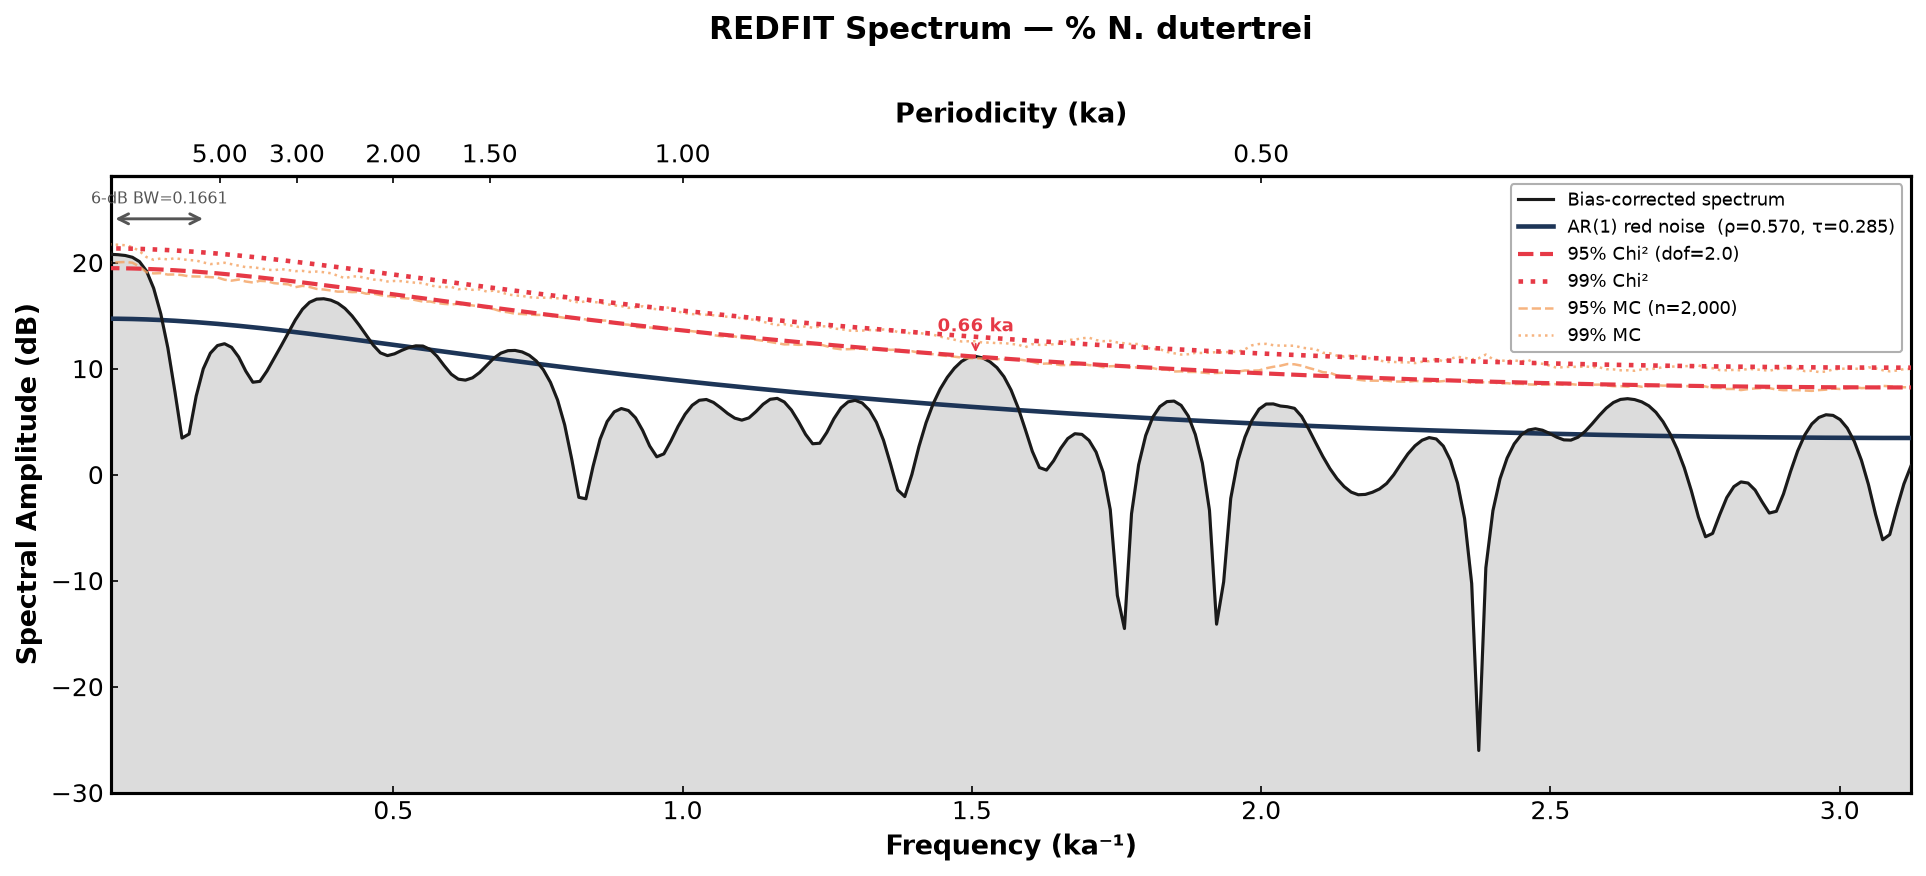

Figure saved: REDFIT_Pct_N_dutertrei_dB_seed1224097580.png
RNG seed used: -1224097580  →  set FIXED_SEED = -1224097580 to reproduce exactly


In [16]:
# =============================================================================
# REDFIT VISUALIZATION  (do not edit)
# =============================================================================

# ── Apply scale (linear or dB) ───────────────────────────────────────────────
if PLOT_SCALE.upper() == 'DB':
    def _sc(a): return 10.0 * np.log10(np.maximum(a, 1e-30))
    y_lbl = 'Spectral Amplitude (dB)'
else:
    def _sc(a): return a
    y_lbl = 'Variance Spectral Density'

y_gxx = _sc(gxxc);      y_red = _sc(gredth)
y_c95 = _sc(ci95_chi2); y_c99 = _sc(ci99_chi2)
y_m95 = _sc(ci95_mc);   y_m99 = _sc(ci99_mc)

_ymin = min(np.min(y_gxx), np.min(y_red)) - (4.0 if PLOT_SCALE.upper()=='DB' else 0)
_ymax = np.max(y_gxx) + (6.0 if PLOT_SCALE.upper()=='DB' else np.max(y_gxx)*0.12)

fig, ax = plt.subplots(figsize=(13, 6))

# Filled spectrum
ax.fill_between(freq, y_gxx, _ymin, color='silver', alpha=0.55, zorder=1)
ax.plot(freq, y_gxx, color='#1a1a1a', lw=1.5, zorder=4, label='Bias-corrected spectrum')
ax.plot(freq, y_red, color='#1D3557', lw=2.2, zorder=3, label=f'AR(1) red noise  (ρ={rho:.3f}, τ={tau:.3f})')

# Chi² levels (primary — Fortran default)
ax.plot(freq, y_c95, '--', color='#E63946', lw=2.0, zorder=5,
        label=f'95% Chi² (dof={dof:.1f})')
ax.plot(freq, y_c99, ':',  color='#E63946', lw=2.2, zorder=5,
        label=f'99% Chi²')

# MC levels (secondary)
ax.plot(freq, y_m95, '--', color='#F4A261', lw=1.2, alpha=0.80, zorder=4,
        label=f'95% MC (n={MC_SIMULATIONS:,})')
ax.plot(freq, y_m99, ':',  color='#F4A261', lw=1.2, alpha=0.80, zorder=4,
        label=f'99% MC')

# ── Annotate significant peaks ────────────────────────────────────────────────
for p in sig_peaks_95:
    fv = freq[p]; pv = 1.0/fv if fv > 0 else float('inf')
    yv = y_gxx[p]
    ax.annotate(f'{pv:.2f} ka',
                xy=(fv, yv),
                xytext=(0, 10), textcoords='offset points',
                ha='center', va='bottom', fontsize=8.5, color='#E63946',
                fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#E63946', lw=0.9))

# ── 6-dB bandwidth reference bar ─────────────────────────────────────────────
_bw_y = _ymax - (_ymax - _ymin) * 0.07
ax.annotate('', xy=(freq[1] + bw6db, _bw_y), xytext=(freq[1], _bw_y),
            arrowprops=dict(arrowstyle='<->', color='#555', lw=1.4))
ax.text(freq[1] + bw6db/2, _bw_y + (_ymax-_ymin)*0.025,
        f'6-dB BW={bw6db:.4f}', ha='center', fontsize=7.5, color='#555')

# ── Axes setup ────────────────────────────────────────────────────────────────
ax.set_xlim([freq[1], freq[-1]])
ax.set_ylim([_ymin, _ymax])
ax.set_xlabel('Frequency (ka⁻¹)', fontsize=13, fontweight='bold')
ax.set_ylabel(y_lbl, fontsize=13, fontweight='bold')
ax.set_title(f'REDFIT Spectrum — {global_proxy_name}', fontsize=15,
             fontweight='bold', pad=30)

# ── Dynamic secondary period axis ─────────────────────────────────────────────
def _f2p(x):
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(x == 0, np.inf, 1.0/x)

secax = ax.secondary_xaxis('top', functions=(_f2p, _f2p))
secax.set_xlabel('Periodicity (ka)', fontsize=13, fontweight='bold', labelpad=10)

secax.set_xticks([5.0, 3.0, 2.0, 1.5, 1.0, 0.5, 0.25])
'''
# Compute period ticks dynamically from the frequency range
_fmax = freq[-1]; _fmin = freq[1]
_pmin = 1.0/_fmax; _pmax = 1.0/_fmin
_raw_ticks = np.geomspace(max(_pmin, 0.1), _pmax, 10)
_nice = [round(p, 2) if p<1 else (round(p,1) if p<5 else round(p)) for p in _raw_ticks]
secax.set_xticks([t for t in _nice if _fmin <= 1.0/t <= _fmax])
'''
secax.get_xaxis().set_major_formatter(ScalarFormatter())

ax.legend(loc='upper right', frameon=True, edgecolor='#aaa', fontsize=8.5,
          framealpha=0.92)
plt.tight_layout()

# ── Save figure ───────────────────────────────────────────────────────────────
_safe = (global_proxy_name.replace('%','Pct').replace(' ','_')
         .replace('.','').replace('/','_'))
_fname = f"REDFIT_{_safe}_{PLOT_SCALE}_seed{abs(idum)}.png"
plt.savefig(_fname, dpi=300, bbox_inches='tight')
plt.show()
print(f"Figure saved: {_fname}")
print(f"RNG seed used: {idum}  →  set FIXED_SEED = {idum} to reproduce exactly")



### How to Read a REDFIT Spectrum — Comprehensive Guide

#### The Y-Axis: Spectral Amplitude in dB
If `PLOT_SCALE = 'dB'`, the y-axis shows $10 \log_{10}(\text{power})$. This compresses the dynamic range of the spectrum, making both strong and weak peaks visible simultaneously. A difference of **10 dB = 10× power ratio**. A peak 3 dB above the red noise curve has twice the power of the red noise at that frequency.

For `PLOT_SCALE = 'Linear'`, the y-axis shows variance spectral density in (proxy units)²/(ka⁻¹). The shape of the spectrum is identical — only the visual compression differs.

#### The Red Noise Curve (dark blue)
This is your **null hypothesis baseline**. It shows what a purely AR(1) red-noise record with the same persistence (τ, ρ) as your data would look like *on average*. The curve always slopes downward from left to right (low frequency to high frequency) — this is the defining signature of red noise.

All peaks in your data spectrum are compared against this curve. A peak that is only slightly above the curve is not necessarily significant — it may simply be the natural variability of a red-noise process. This is why we need the false-alarm levels.

#### The False-Alarm Levels

**Chi²-based (red lines):** The 95% dashed line means: if the data were pure AR(1) red noise, we would expect to see a peak at this height (or higher) at any given frequency with only 5% probability. The 99% dotted line is the 1% threshold.

**MC-based (orange lines):** Empirically derived from your actual Monte Carlo simulations. They naturally account for any non-Gaussianity in the red noise that the chi-squared assumption may miss.

**Interpreting Chi² vs MC agreement:**

> If a peak exceeds **both** the 95% Chi² and 95% MC levels simultaneously, this is strong evidence that the peak is not red noise. If only one threshold is exceeded, be cautious.

#### The 6-dB Bandwidth Bar
The horizontal double arrow in the upper left shows the **frequency resolution limit**. Two spectral peaks separated by less than this bandwidth *cannot be resolved as distinct*. A pair of closely-spaced peaks may appear as a single broad hump. Never report two periodicities as independent if their frequencies are within the 6-dB bandwidth of each other.

#### Annotated Peak Labels
Peaks above the 95% Chi² threshold are automatically annotated with their period in ka. These are the starting point for interpreting your results, but always cross-check:

1. Is the period physically meaningful for the known forcing mechanisms (orbital: 100 ka, 41 ka, 23 ka; ENSO: 2–8 years; Bond cycles: ~1.5 ka)?
2. Is the period well above the Nyquist period (i.e., not potentially an alias)?
3. Does the WWZ wavelet show this period as persistently active through time (not just a brief transient)?

#### Common Mistakes to Avoid

| Mistake | Why It Is Wrong |
|---------|----------------|
| Reporting a peak that only just crosses the 95% line as "significant" | At 95%, 1 in 20 frequencies will cross by chance alone |
| Reporting two peaks within the 6-dB bandwidth as two separate cycles | They may be one broadened peak |
| Ignoring a high MC level that disagrees with Chi² | The empirical test is more robust for non-Gaussian data |
| Reporting a peak at or near the Nyquist frequency | This may be an aliased high-frequency signal |
| Not checking whether the peak is inside the WWZ COI | REDFIT cannot detect the temporal non-stationarity |



---
## Section 10: The WWZ Wavelet: Full Theory

### 10.1 The Limitation of REDFIT

REDFIT assumes **stationarity**: that any periodic cycle, if it exists, is present throughout the entire record at constant amplitude. This is often false in paleoclimate:
- A glacial cycle may only become active after some threshold state is reached
- An El Niño teleconnection may be modulated by background SST state
- A Milankovitch signal may be amplitude-modulated by ice-sheet state

REDFIT averages over the entire record, so a cycle that was active for only half the record will appear half as strong as if it were active throughout — and may fall below the significance threshold even if it was locally very strong.

### 10.2 Wavelet Analysis

A wavelet transform slides a **localized oscillating function** (the wavelet) across the time series, computing how well a sinusoid of each frequency fits the data at each point in time. The result is a **2D map** (time × frequency) of spectral amplitude — called a **scalogram**.

The **Morlet wavelet** (the basis of most geological wavelet analyses) is a complex sinusoid modulated by a Gaussian envelope:

$$\psi(t) = e^{i\omega_0 t} \cdot e^{-t^2/2}$$

The width of the Gaussian envelope controls the **time-frequency trade-off** — this is the Heisenberg-Gabor uncertainty principle: you cannot simultaneously have perfect time resolution AND perfect frequency resolution.

### 10.3 The Foster (1996) WWZ — Handling Uneven Data

Standard Morlet wavelet analysis requires even spacing. **Foster (1996)** modified the approach for unevenly sampled data using the **Weighted Wavelet Z-Transform (WWZ)**. Instead of convolving with the wavelet, WWZ performs a **weighted least-squares fit** of a sinusoid to data near each time-frequency target point, with weights given by the Gaussian:

$$w(t_i; t_0, f) = e^{-c \cdot \omega^2 (t_i - t_0)^2}$$

where $c$ is the **decay constant** (also called `WWZ_DECAY`).

### 10.4 The `c` Parameter — Time-Frequency Trade-off

The decay constant $c$ controls the width of the Gaussian window:

| `c` value | Time resolution | Frequency resolution | Appearance |
|----------|----------------|---------------------|------------|
| 0.001 | Excellent | Poor | "Blobs" — hard to identify exact frequency |
| **0.0125** | **Balanced** | **Balanced** | **Standard for paleoclimate (recommended)** |
| 0.05 | Poor | Excellent | Narrow bands — precise frequency, blurred time |
| 0.1 | Very poor | Very good | Suitable only for very long records |

There is no universally "correct" value — it depends on your scientific question. If you need to know **when** a cycle was active: use lower c. If you need to know **exactly what period** a cycle has: use higher c.

### 10.5 The Cone of Influence (COI)

Near the edges of the time series, the wavelet extends beyond the data boundaries and the results are unreliable. The **Cone of Influence** (the region inside the dashed curve) marks where edge effects become significant. Data *outside* the COI (in the shaded region at the edges) **must not be interpreted** — it is a mathematical artefact of the boundary, not a real signal.

Rule of thumb: the COI width at any given period is approximately equal to the period itself. A 5 ka cycle needs ~5 ka of buffer from each end of the record.

### 10.6 REDFIT vs WWZ — When to Use Each

| Question | Method |
|---------|--------|
| "Does my record contain any persistent cycle at all?" | REDFIT (always do this first) |
| "Was this cycle present throughout the record or only part of it?" | WWZ |
| "Did the dominant period shift through time?" | WWZ |
| "How strong is this cycle on average compared to red noise?" | REDFIT |
| "I only have 100 data points — is a wavelet reliable?" | REDFIT only (WWZ needs more points) |
| "I want a single publishable significance test" | REDFIT Chi² (most widely accepted) |
| "I want to understand the temporal evolution of this signal" | WWZ |



---
## Section 11: WWZ Parameters: Full Reference Guide

---

### `WWZ_DECAY` — Wavelet Decay Constant (c)
**Fortran equivalent:** N/A (a `pyleoclim` parameter)  
**Default:** 0.0125  
**Reasonable range:** 0.001 – 0.10

This is the most scientifically important WWZ parameter. It controls the trade-off between time resolution and frequency resolution (see Section 10.4).

For **Holocene paleoclimate records** (0–15 ka, typical Δt ~ 50–100 years), 0.0125 is optimal.  
For **longer records** (Pleistocene, > 500 ka), consider 0.025–0.05.  
For **sub-centennial records** (varved sediments, tree rings), consider 0.005–0.01.

> ⚠️ Do not compare scalograms with different `c` values side by side — the apparent width of features changes entirely.

---

### `WWZ_SURROGATES` — Number of Monte Carlo Surrogates
**Default:** 200  
**Reasonable range:** 100 – 1000

The WWZ significance test generates `WWZ_SURROGATES` synthetic AR(1) records using uneven sampling intervals (the `uar1` method), computes the full scalogram for each, and extracts the 95th-percentile amplitude at each time-frequency point. White contours on the scalogram indicate where the data exceeds this threshold.

| Surrogates | Run time (typical) | 95% level stability | Use for |
|-----------|--------------------|--------------------|----|
| 100 | ~3 min | ±7% | Quick preview |
| **200** | **~6 min** | **±5%** | **Standard published work** |
| 500 | ~15 min | ±3% | High-confidence publication |
| 1000 | ~30 min | ±2% | Final figures, critical analysis |

---

> **Workflow recommendation:** First run with `WWZ_SURROGATES = 200` to check the figure. Once satisfied with the analysis and parameters, increase to 500 or 1000 for final publication figures.


In [17]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  USER INPUT BLOCK 4 — WWZ Parameters                         ║
# ║  Read Section 11 before changing these values.               ║
# ╚══════════════════════════════════════════════════════════════╝

WWZ_DECAY      = 0.0125   # c — time-frequency decay constant (0.001–0.10)
WWZ_SURROGATES = 200      # number of AR(1) surrogates for significance (100–1000)

print(f"WWZ parameters set: c={WWZ_DECAY}, surrogates={WWZ_SURROGATES}")
print("Run the next cell to compute the WWZ scalogram.")


WWZ parameters set: c=0.0125, surrogates=200
Run the next cell to compute the WWZ scalogram.



---
## Section 12: Running the WWZ Analysis

The computation cell below performs three steps:

**Step 1 — Standardize the time series**
The proxy data is standardized to zero mean and unit variance before wavelet analysis. This removes the influence of the proxy's physical units and absolute offset on the wavelet amplitude, making comparisons across proxies possible.

**Step 2 — Compute the WWZ scalogram**
`pyleoclim` computes the WWZ amplitude at every combination of (time, frequency) in the grid. The `c=WWZ_DECAY` parameter is correctly passed here. This is the computationally expensive step — it scales as O(N × N_freq × N_time).

**Step 3 — Significance testing**
`WWZ_SURROGATES` AR(1) synthetic records are generated using the **uneven** sampling times (`method='uar1'`), their scalograms computed, and the 95th-percentile amplitude extracted at each time-frequency point. The white contours on the final plot mark regions where the data scalogram exceeds this threshold.

> ⚠️ The WWZ computation and significance testing can take several minutes. Do not interrupt the cell — let it complete.


---
## A Note on Multiprocessing in Jupyter (Windows & macOS)

The pyleoclim library uses parallel processing (multiprocessing.ProcessPoolExecutor) by default to speed up the calculation of significance surrogates. 

While this works flawlessly on **Linux**, it frequently causes a BrokenProcessPool crash when run inside Jupyter Notebooks on **Windows** and **macOS**. This is because Windows and newer versions of macOS use the spawn method for creating processes, which fails to correctly inherit the interactive Jupyter environment, causing the child processes to crash.

To make this notebook universally robust and reproducible on any operating system, the cell below dynamically "monkey-patches" the library to use a ThreadPoolExecutor instead. This runs the calculation safely on a single core, avoiding the crash.


In [19]:
# --- MONKEY PATCH FOR WINDOWS JUPYTER MULTIPROCESSING ---
import pyleoclim.core.multipleseries
import pyleoclim.core.coherences
import concurrent.futures
from contextlib import contextmanager

@contextmanager
def _dummy_process_pool():
    # Force pyleoclim to use a Thread pool instead of a Process pool
    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as executor:
        yield executor

pyleoclim.core.multipleseries._get_process_pool = _dummy_process_pool
pyleoclim.core.coherences._get_process_pool = _dummy_process_pool
print("Pyleoclim successfully patched for Windows Jupyter!")
# --------------------------------------------------------

Pyleoclim successfully patched for Windows Jupyter!


In [ ]:
# =============================================================================
# MULTIPROCESSING SAFETY PATCH
# =============================================================================
import pyleoclim.core.multipleseries
import pyleoclim.core.coherences
import concurrent.futures
from contextlib import contextmanager

@contextmanager
def _dummy_process_pool():
    # Force pyleoclim to use a Thread pool (1 worker) instead of a Process pool
    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as executor:
        yield executor

pyleoclim.core.multipleseries._get_process_pool = _dummy_process_pool
pyleoclim.core.coherences._get_process_pool = _dummy_process_pool

print("Multiprocessing patched. Safe to proceed on Windows/macOS.")


In [20]:
# =============================================================================
# WWZ EXECUTION  (do not edit)
# =============================================================================
print(f"Starting WWZ analysis on '{global_proxy_name}'...")
print(f"  c (decay) = {WWZ_DECAY},  surrogates = {WWZ_SURROGATES}")

# Step 1: Build pyleoclim Series and standardize
ts     = pyleo.Series(time=global_time, value=global_proxy,
                      time_name='Age', time_unit='ka',
                      value_name=global_proxy_name)
ts_std = ts.standardize()
print("  Standardized series created.")

# Step 2: Compute WWZ scalogram
# In pyleoclim 1.x the decay constant 'c' is passed via the settings dict.
# In pyleoclim 0.x it could be passed directly — the try/except handles both.
print("  Computing WWZ scalogram...")
try:
    scalogram = ts_std.wavelet(method='wwz', settings={'c': WWZ_DECAY})
except TypeError:
    # Fallback for older pyleoclim API (pre-1.x)
    scalogram = ts_std.wavelet(method='wwz', c=WWZ_DECAY)
print("  Scalogram complete.")

# Step 3: Significance testing against uneven AR(1) surrogates
print(f"  Running {WWZ_SURROGATES} AR(1) significance surrogates (uar1)...")
scalogram_sig = scalogram.signif_test(method='uar1', number=WWZ_SURROGATES)
print("  WWZ analysis complete. Run the visualization cell.")

Starting WWZ analysis on '% N. dutertrei'...
  c (decay) = 0.0125,  surrogates = 200
Time axis values sorted in ascending order
  Standardized series created.
  Computing WWZ scalogram...
  Scalogram complete.
  Running 200 AR(1) significance surrogates (uar1)...


Performing wavelet analysis on individual series: 100%|██████████| 200/200 [37:03<00:00, 11.12s/it]

  WWZ analysis complete. Run the visualization cell.


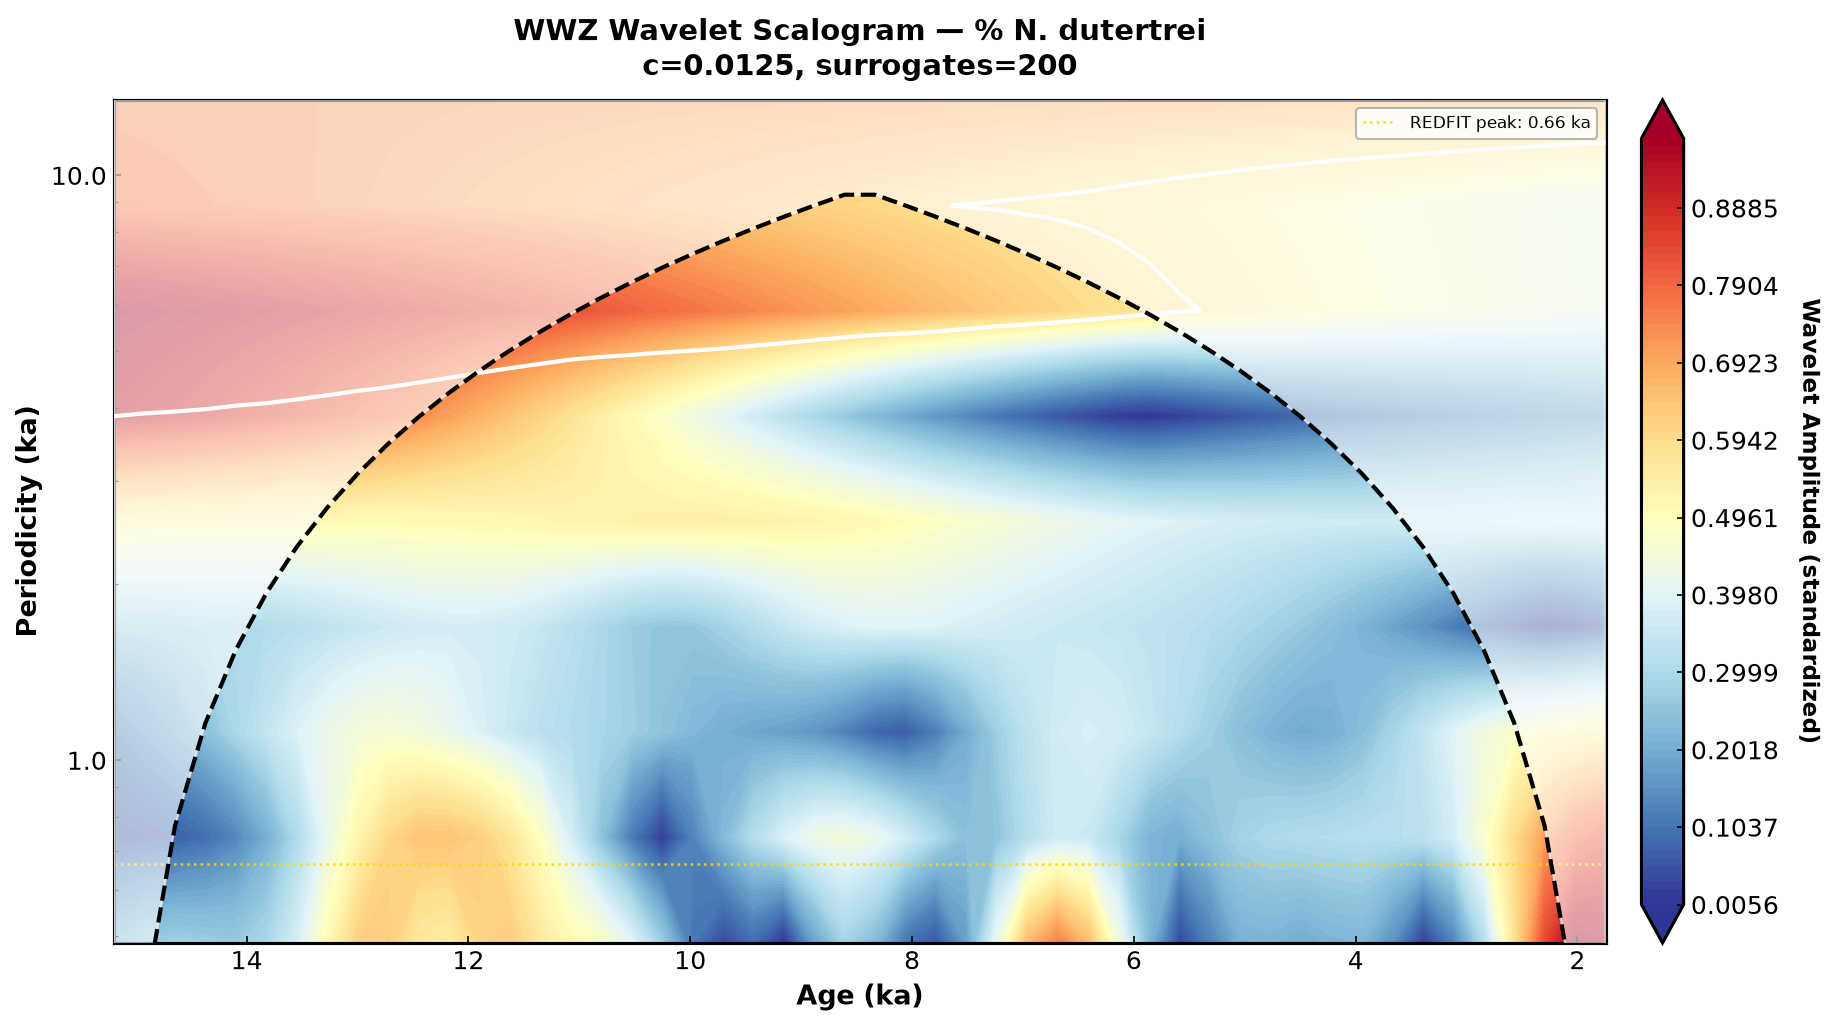

Figure saved: WWZ_Pct_N_dutertrei_c0.0125_n200.png


In [21]:
# =============================================================================
# WWZ VISUALIZATION  (do not edit)
# =============================================================================

# ── Extract arrays — handle pyleoclim API differences gracefully ──────────────
time_arr   = scalogram_sig.time
freq_arr   = scalogram_sig.frequency
period_arr = 1.0 / freq_arr
coi        = scalogram_sig.coi
amplitude  = scalogram_sig.amplitude

try:
    sig_matrix = scalogram_sig.signif_qs.scalogram_list[0].amplitude
except AttributeError:
    try:
        sig_matrix = scalogram_sig.signif_qs.amplitude
    except AttributeError:
        raise RuntimeError(
            "Cannot find significance matrix in scalogram_sig.  "
            "Check your pyleoclim version."
        )

# Ensure amplitude is (period × time) for contourf
if amplitude.shape == (len(time_arr), len(period_arr)):
    amplitude  = amplitude.T
    sig_matrix = sig_matrix.T

# ── Build figure ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))

levels = np.linspace(np.nanmin(amplitude), np.nanmax(amplitude), 100)
cf = ax.contourf(time_arr, period_arr, amplitude,
                 levels=levels, cmap='RdYlBu_r', extend='both')

# 95% significance contours (white)
ratio = amplitude / np.where(sig_matrix == 0, np.nan, sig_matrix)
ax.contour(time_arr, period_arr, ratio,
           levels=[1.0], colors='white', linewidths=2.0, zorder=5)

# Cone of Influence (COI)
ax.plot(time_arr, coi, color='black', lw=2, ls='--', zorder=6)
ax.fill_between(time_arr, coi, period_arr.max() * 1.5,
                color='white', alpha=0.60, zorder=4)

# ── Mark REDFIT significant periods as horizontal reference lines ─────────────
for p in sig_peaks_95:
    fv = freq[p]; pv = 1.0/fv if fv > 0 else None
    if pv and period_arr.min() <= pv <= period_arr.max():
        ax.axhline(pv, color='#FFD700', lw=1.2, ls=':', alpha=0.9,
                   label=f'REDFIT peak: {pv:.2f} ka')

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_yscale('log')
ax.set_ylim([period_arr.min(), period_arr.max()])
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

if time_arr[-1] > time_arr[0]:
    ax.invert_xaxis()   # geological convention

ax.set_xlabel('Age (ka)', fontsize=13, fontweight='bold')
ax.set_ylabel('Periodicity (ka)', fontsize=13, fontweight='bold')
ax.set_title(f'WWZ Wavelet Scalogram — {global_proxy_name}\n'
             f'c={WWZ_DECAY}, surrogates={WWZ_SURROGATES}',
             fontsize=14, fontweight='bold', pad=12)

cbar = fig.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label('Wavelet Amplitude (standardized)', rotation=270,
               labelpad=20, fontweight='bold', fontsize=11)

handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles[:5], labels[:5], loc='upper right', fontsize=8,
              framealpha=0.85, edgecolor='#aaa')

plt.tight_layout()

# ── Save figure ───────────────────────────────────────────────────────────────
_safe = (global_proxy_name.replace('%','Pct').replace(' ','_')
         .replace('.','').replace('/','_'))
_wfname = f"WWZ_{_safe}_c{WWZ_DECAY}_n{WWZ_SURROGATES}.png"
plt.savefig(_wfname, dpi=300, bbox_inches='tight')
plt.show()
print(f"Figure saved: {_wfname}")



### How to Read a WWZ Scalogram — Comprehensive Guide

#### The Colormap (RdYlBu_r)
High wavelet amplitude (warm colors — red/orange) indicates that a sinusoidal signal at that period is a good fit to the data at that time. Low amplitude (cool colors — blue) indicates the data is not well described by that periodicity at that time.

The colormap is **perceptually uniform and colorblind-safe** — every step in color represents an equal step in amplitude. (Unlike the `jet` colormap used in many papers, which has known perceptual distortions that can mislead interpretation.)

#### White Significance Contours
Where the scalogram amplitude exceeds the 95th percentile of the uneven AR(1) surrogate distribution, a white contour is drawn. A feature with **no white contour** is not statistically distinguishable from red noise, regardless of how visually prominent it appears.

#### The Cone of Influence (COI — black dashed curve)
**The most important graphical element to understand.** Inside the COI (below the curve): results are reliable. Outside the COI (above the curve, in the shaded region at the left and right edges): results are dominated by edge effects and must not be interpreted.

The COI boundary is approximately at period ≈ time from the edge. A 5 ka periodicity needs ~5 ka of data on either side to be reliably detected. Near the edges of your record, only short-period signals are trustworthy.

**Example:** In a 15 ka record:
- A 1 ka cycle is reliable from ~1 to ~14 ka
- A 5 ka cycle is only reliable from ~5 to ~10 ka
- A 10 ka cycle cannot be detected at all (COI fills the entire scalogram)

#### Gold Dashed Lines — REDFIT Cross-Reference
The horizontal gold dashed lines mark the significant periods identified by REDFIT. If a WWZ bright region with a white contour aligns with a gold dashed line, both methods independently confirm the same periodicity — this is the strongest possible evidence for a real climate cycle.

#### Common Mistakes in WWZ Interpretation

| Mistake | Why It Is Wrong |
|---------|----------------|
| Interpreting a bright region in the shaded (COI) zone | Edge artefact — mathematically unreliable |
| Reporting a feature with no white contour as significant | Not statistically distinguishable from red noise |
| Concluding a cycle "appeared" at a certain time based on amplitude variation | Amplitude variation can also reflect changing data spacing, not just changing cycle strength |
| Comparing scalograms with different `c` values as if they are equivalent | The same physical signal will have different widths depending on `c` |

#### Reconciling REDFIT and WWZ Results

| REDFIT | WWZ | Interpretation |
|--------|-----|----------------|
| Peak at period P, above 95% | Bright region at P, inside COI, with white contour | **Strong**: P is a persistent, significant cycle |
| Peak at period P, above 95% | No clear feature at P in WWZ | P may be real but intermittent/episodic — REDFIT averages it up |
| No peak at P in REDFIT | Bright region at P in WWZ with white contour | P was briefly active but not long enough to emerge from REDFIT average |
| No peak at P in REDFIT | No feature at P in WWZ | P is not present in this record |


In [13]:
# =============================================================================
# AUTOMATED RESULTS EXPORT & REPRODUCIBILITY LOG  (do not edit)
# =============================================================================
print(f"Exporting results for: {global_proxy_name}")

# safe_name defined FIRST, before any branch that uses it
safe_name = (global_proxy_name
             .replace('%', 'Pct').replace(' ', '_')
             .replace('.', '').replace('/', '_'))

# ── Significant peaks table ───────────────────────────────────────────────────
export_rows = []
for p in sig_peaks_95:
    fv  = freq[p]
    pv  = 1.0/fv if fv > 0 else np.inf
    lv  = '99%' if p in sig_peaks_99 else '95%'
    mc  = 'Yes' if p in sig_peaks_95mc else 'No'
    export_rows.append({
        'Proxy'              : global_proxy_name,
        'Period_ka'          : round(pv, 4),
        'Frequency_per_ka'   : round(fv, 6),
        'Chi2_level'         : lv,
        'Also_sig_MC_95pct'  : mc,
        'Spectral_Power'     : round(float(gxxc[p]), 6),
    })

if export_rows:
    peaks_df     = pd.DataFrame(export_rows)
    peaks_csv    = f"Significant_Peaks_{safe_name}.csv"
    peaks_df.to_csv(peaks_csv, index=False)
    print(f"\nSignificant peaks saved to: {peaks_csv}")
    display(peaks_df)
else:
    print("\nNo peaks exceeded the 95% Chi² threshold for this dataset/proxy.")

# ── Reproducibility log (JSON — machine readable) ─────────────────────────────
import json
log = {
    'date'           : datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'python_version' : sys.version,
    'file'           : FILE_NAME,
    'sheet'          : SHEET_NAME,
    'age_column'     : AGE_COLUMN,
    'proxy_column'   : PROXY_COLUMN,
    'n_samples'      : int(len(global_time)),
    'age_range'      : [float(global_time.min()), float(global_time.max())],
    'REDFIT': {
        'OVERSAMPLING'   : OVERSAMPLING,
        'MAX_FREQ_FACTOR': MAX_FREQ_FACTOR,
        'WOSA_SEGMENTS'  : WOSA_SEGMENTS,
        'WINDOW_TYPE'    : WINDOW_TYPE,
        'MC_SIMULATIONS' : MC_SIMULATIONS,
        'FIXED_SEED'     : FIXED_SEED,
        'actual_seed'    : int(idum),
        'tau_ka'         : round(float(tau), 6),
        'rho'            : round(float(rho), 6),
        'dof'            : round(float(dof), 4),
        'bw6db_per_ka'   : round(float(bw6db), 6),
        'PLOT_SCALE'     : PLOT_SCALE,
    },
    'WWZ': {
        'WWZ_DECAY'      : WWZ_DECAY,
        'WWZ_SURROGATES' : WWZ_SURROGATES,
    },
    'significant_peaks': export_rows,
}
log_fn = f"Reproducibility_Log_{safe_name}.json"
with open(log_fn, 'w') as f:
    json.dump(log, f, indent=2)

print(f"Reproducibility log saved to: {log_fn}")
print()
print("=" * 58)
print("  ANALYSIS COMPLETE")
print("=" * 58)
print(f"  Proxy   : {global_proxy_name}")
print(f"  Seed    : {idum}  →  FIXED_SEED = {idum}")
print(f"  Peaks   : {len(export_rows)} significant at 95% Chi²")
print("=" * 58)


Exporting results for: % N. dutertrei

Significant peaks saved to: Significant_Peaks_Pct_N_dutertrei.csv


,Proxy,Period_ka,Frequency_per_ka,Chi2_level,Also_sig_MC_95pct,Spectral_Power
0,% N. dutertrei,0.6638,1.506456,95%,Yes,13.141525


Reproducibility log saved to: Reproducibility_Log_Pct_N_dutertrei.json

  ANALYSIS COMPLETE
  Proxy   : % N. dutertrei
  Seed    : -749342147  →  FIXED_SEED = -749342147
  Peaks   : 1 significant at 95% Chi²
